Devadharshan S

CH.SC.U4CSE24113

1. A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point
average) and prestige of the undergraduate institution, effect admission into graduate school. The response
variable, admit/don't admit, is a binary variable.

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [6]:
# Load the dataset
url = 'https://stats.idre.ucla.edu/stat/stata/dae/binary.dta'
df = pd.read_stata(url)

In [7]:
# Display the first few rows
print("Dataset Head:\n", df.head())

Dataset Head:
    admit    gre   gpa  rank
0    0.0  380.0  3.61   3.0
1    1.0  660.0  3.67   3.0
2    1.0  800.0  4.00   1.0
3    1.0  640.0  3.19   4.0
4    0.0  520.0  2.93   4.0


In [17]:
# Checking for any null values in dataset
print(df.isnull().sum())

admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [9]:
# Assign dependent and independent variables
# 'admit' is the target binary variable. 'gre', 'gpa', and 'rank' (prestige) are features.
X = df[['gre', 'gpa', 'rank']]
y = df['admit']

In [10]:
# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [11]:
# Fit the Logistic Regression Model
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Make Predictions
y_pred = model.predict(x_test)

In [14]:
# Evaluation Metrics & Confusion Matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix: \n', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score: ', Accuracy_score)
print('Accuracy in Percentage: ', int(Accuracy_score * 100), '%')


Confusion Matrix: 
 [[50  4]
 [23  3]]
Accuracy Score:  0.6625
Accuracy in Percentage:  66 %


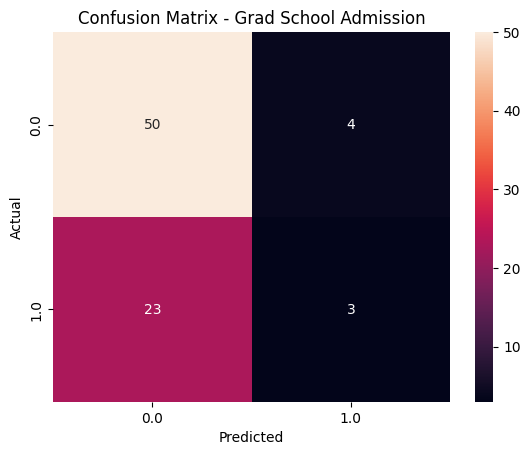

In [15]:
# Plotting the Confusion Matrix Heatmap
conf_mat_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat_df, annot=True)
plt.title('Confusion Matrix - Grad School Admission')
plt.show()